# Chapter 61: Playground Series Strategy

**How much of the public leader's visible advantage is still there on private rows as more near-equal candidates are screened?**

A dense Playground leaderboard rewards many small experiments, and every experiment is one more draw against the same 400 public rows. The chapter asks for paired local evidence and a preserved supported candidate rather than the public leader.

*Constructed data. The visible lead, the earned lead and the regrets are properties of this generator and of the 20% public share; they illustrate selection noise, not a claim about any actual competition.*

## The experiment

Twelve constructed competitions. Each has 1,500 training rows, 2,000 test rows (400 public, 1,600 private) and a regression target with noise standard deviation 3. Candidates are near-duplicate ridge recipes: each drops two of 30 features, trains on a random 75% of the rows and picks its own penalty, and the number of candidates screened is the control. For every competition, 300 random public/private splits are drawn. The public leader is picked in each, and its RMSE is compared with the median candidate on public rows, on private rows and on 10,000 fresh rows. A second rule picks the candidate with the best 5-fold cross-validation RMSE on the training rows, and a third picks at random.

In [1]:
import numpy as np

from kaggle_companion.activities._common import clean

SEED = 61
DATASETS = 12                        # independent constructed competitions; every estimate is their mean
SPLITS = 300                         # random public/private splits of the test rows per competition
F, N_TRAIN, N_TEST, N_FRESH = 30, 1500, 2000, 10000
PUBLIC_SHARE = 0.2                   # 400 public rows, 1,600 private rows
NOISE = 3.0


def make_data(rng, beta, n):
    X = rng.normal(size=(n, F))
    return X, X @ beta + rng.normal(0, NOISE, n)


def ridge(X, y, alpha):
    """Closed-form ridge without an intercept (the constructed target has mean zero)."""
    return np.linalg.solve(X.T @ X + alpha * np.eye(X.shape[1]), X.T @ y)


def rmse(y, pred):
    return float(np.sqrt(np.mean((y - pred) ** 2)))


def one_competition(n_candidates, seed):
    """Candidates are near-duplicate ridge recipes: each drops two features, trains on a random 75% of the rows and
    picks its own penalty. Returns each candidate's squared errors on the test rows, its 5-fold CV RMSE on the
    training rows and its RMSE on 10,000 fresh rows (the 'truth' that nobody gets to see in a real competition)."""
    rng = np.random.default_rng(seed)
    beta = rng.normal(0, 0.35, F)
    Xtr, ytr = make_data(rng, beta, N_TRAIN)
    Xte, yte = make_data(rng, beta, N_TEST)
    Xfr, yfr = make_data(rng, beta, N_FRESH)
    folds = rng.permutation(N_TRAIN) % 5
    err_test, cv, truth = [], [], []
    for _ in range(n_candidates):
        cols = np.sort(rng.choice(F, F - 2, replace=False))
        alpha = 10 ** rng.uniform(-1, 2)
        rows = rng.random(N_TRAIN) < 0.75
        w = ridge(Xtr[rows][:, cols], ytr[rows], alpha)
        err_test.append((yte - Xte[:, cols] @ w) ** 2)
        truth.append(rmse(yfr, Xfr[:, cols] @ w))
        oof = np.zeros(N_TRAIN)
        for k in range(5):
            fit = rows & (folds != k)
            oof[folds == k] = Xtr[folds == k][:, cols] @ ridge(Xtr[fit][:, cols], ytr[fit], alpha)
        cv.append(rmse(ytr, oof))
    return np.array(err_test), np.array(cv), np.array(truth), rng


def run(n_candidates):
    n_pub = int(PUBLIC_SHARE * N_TEST)
    per = {k: [] for k in ("public_shown", "private_earned", "truth_earned", "regret_public", "regret_cv", "regret_random",
                           "leader_stays", "leader_is_best")}
    for d in range(DATASETS):
        err, cv, truth, rng = one_competition(n_candidates, SEED * 100 + d)
        mask = np.zeros((SPLITS, N_TEST))
        for s in range(SPLITS):
            mask[s, rng.permutation(N_TEST)[:n_pub]] = 1
        sp = np.sqrt(mask @ err.T / n_pub)                              # public RMSE of every candidate, per split
        sv = np.sqrt((1 - mask) @ err.T / (N_TEST - n_pub))             # private RMSE of every candidate, per split
        pick = sp.argmin(1)                                             # the public leader in each split
        rows = np.arange(SPLITS)
        per["public_shown"].append(float(np.mean(np.median(sp, 1) - sp[rows, pick])))
        per["private_earned"].append(float(np.mean(np.median(sv, 1) - sv[rows, pick])))
        per["truth_earned"].append(float(np.mean(np.median(truth) - truth[pick])))
        per["regret_public"].append(float(np.mean(truth[pick] - truth.min())))
        per["regret_cv"].append(float(truth[cv.argmin()] - truth.min()))
        per["regret_random"].append(float(truth.mean() - truth.min()))
        per["leader_stays"].append(float(np.mean(sv.argmin(1) == pick)))
        per["leader_is_best"].append(float(np.mean(truth.argmin() == pick)))
    mean = {k: float(np.mean(v)) for k, v in per.items()}
    return clean({"candidates": n_candidates, **mean, "per_dataset": per, "datasets": DATASETS, "splits": SPLITS,
                  "public_rows": n_pub, "private_rows": N_TEST - n_pub, "train_rows": N_TRAIN})


## Measure it across the control

The control is **candidates screened against the public leaderboard**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch61 import explain

VALUES = [3, 10, 30, 100]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                                       3                     10                     30                    100
Lead shown on public rows                          0.042                  0.045                  0.052                  0.062
Lead earned on private rows                        0.029                  0.021                  0.018                  0.021
Lead earned on fresh rows                          0.024                  0.019                  0.017                  0.020
Public leader also private leader          58% of splits          29% of splits          23% of splits           8% of splits
Regret: public / CV / random       0.005 / 0.003 / 0.025  0.013 / 0.006 / 0.041  0.017 / 0.009 / 0.042  0.019 / 0.011 / 0.048


## Look at it

The figure shows the default setting, candidates screened against the public leaderboard = 30.

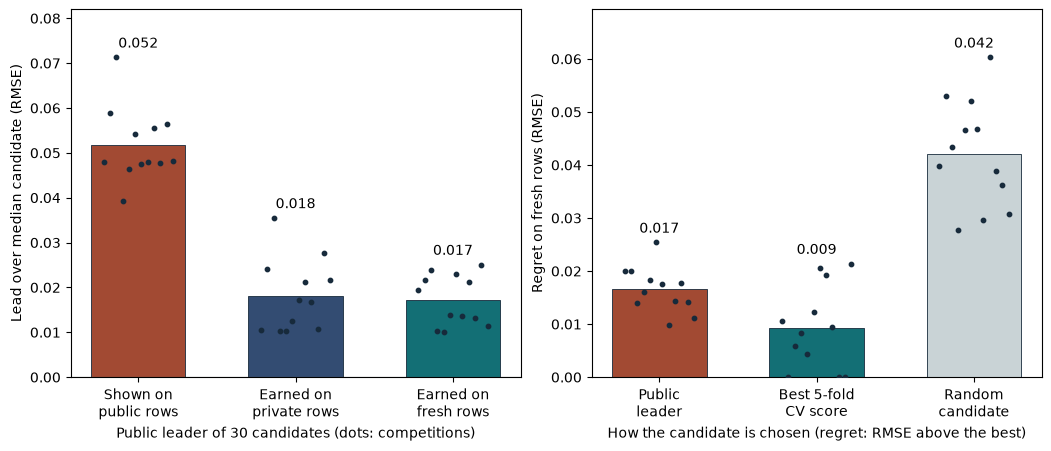

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch61 import draw, NCOLS, HEIGHT

DEFAULT = 30
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 30 candidates the public leader looks 0.052 RMSE better than the median candidate on the public rows, but earns 0.018 on private rows and 0.017 on fresh rows: 0.052 - 0.018 = 0.034 of the visible lead was selection noise, and 35% of it is real. The public leader is also the private leader in 23% of splits. Against the best candidate, picking by public score costs 0.017 RMSE on fresh rows, picking by cross-validation 0.009 and picking at random 0.042.

- Noise in the visible lead: 0.052 - 0.018 = 0.034 (shown minus earned on private rows).
- Share of the visible lead that is real: 0.018 / 0.052 = 0.351.
- Cross-validation against the public leader: 0.017 - 0.009 = 0.008 less regret.
- Public leader against a random pick: 0.042 - 0.017 = 0.025 less regret.

## Apply this to your competition

- Record which candidates were chosen using public feedback, and count how many were screened against it.
- Rank candidates on paired local folds that use far more rows than the public sample; treat a small public lead as a tie-breaker.
- Use the final submission slots for candidates with different supported assumptions, not only the top public scores.
- Preserve the best locally supported candidate and its artifacts before any late move made for a public gain.

Book location: Chapter 61, Reading the Leaderboard: Signal vs. Noise.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)